In [ ]:
# PET VAE Model Evaluation: PIB and FBB Tracer Analysis
#
# This notebook evaluates the trained VAE model on different PET tracers (PIB and FBB).
# Main purposes:
# 1. Extract latent features for PIB and FBB tracers
# 2. Calculate reconstruction quality metrics (SSIM, PSNR)
# 3. Save latent features for downstream analysis
#
# Core imports for model evaluation
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from torch.utils.data import Dataset, DataLoader

import re
import os, fnmatch
import sys

# Image quality metrics for reconstruction evaluation
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [2]:
from addl_models_bimodel_pytorch import VAE_1modality_PET

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 51888 bytes to addl_models_bimodel_pytorch.py


In [ ]:
# EXPERIMENT CONFIGURATION
# Date identifier for this evaluation run (should match training date)
date = '26_05_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [ ]:
# Load metadata containing image paths and sample information
# This metadata is used to identify PIB and FBB tracer samples
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]  # Remove first column (likely index column)

In [ ]:
# Load additional metadata with research group information
# This is used to filter samples by tracer type (PIB/FBB) and exclude AD group
meta2 = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/metafile_completing/metafile_completed_ADNI_A4_processed_02_06_2024_shuffled.csv')


In [ ]:
# PIB TRACER DATA PREPARATION
# Filter PIB samples excluding AD research group, then find matching file paths
#
# Process:
# 1. Filter metadata for PIB tracer samples (excluding AD group)
# 2. Match sample IDs to actual file paths in the data directory
# 3. Collect all matching file paths for PIB evaluation



# Filter PIB samples: exclude AD research group (likely to focus on non-AD cases)
pib = meta2[(meta2.modality_subtype == 'PIB') & (meta2['Research.Group'] != 'AD')].copy()

# Path to folder containing preprocessed PET scans
folder_path = "/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/"

# Collect matching file paths by matching sample IDs to filenames
# NOTE: This assumes sample IDs are embedded in filenames
file_paths = []
for file_name in os.listdir(folder_path):
    for sample_id in pib['Image.Data.ID']:
        if sample_id in file_name:  # Check if ID is part of the filename
            file_paths.append(os.path.join(folder_path, file_name))

# DEBUG: Print found file paths (can be commented out for production)
print(file_paths)


In [ ]:
# DEBUG CELL - Check number of PIB files found
# Uncomment to verify number of matching files
#len(file_paths)

119

In [ ]:
# Load normalization statistics from training data
# These statistics are used to normalize evaluation data consistently with training
# CRITICAL: Using training statistics ensures consistent preprocessing
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")

# Extract quantile thresholds for clipping outliers
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']
p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']
p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']
p_quant999 = stat['p_quant999']  # 99.9th percentile (used for normalization)
m_quant999 = stat['m_quant999']

# Extract mean and std for z-score normalization (if needed)
p_std = stat['p_std']
m_std = stat['m_std']

# Extract clipped statistics (after removing outliers)
p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

# Extract min/max values after clipping (used for min-max normalization)
p_min_clip = stat['p_mim_clip']  # Note: typo in original file ('mim' instead of 'min')
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [17]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1
#brain_mask = np.stack([brain_mask] * 2, axis=-1)

In [ ]:
class PETMRISliceDataset(Dataset):
    """
    PyTorch Dataset for 2D slices extracted from PET scans.
    
    This dataset extracts 2D slices from 3D PET volumes along a specified axis.
    Used for model evaluation on PIB and FBB tracers.
    
    
    Parameters:
    - list_IDs_pet: List of file paths to PET scan files
    - slice_axis: Axis along which to extract slices (0=sagittal, 1=coronal, 2=axial)
    - brain_mask: Binary mask to apply to slices
    - pet_minimum/maximum: Min/max values for normalization (from training statistics)
    - pet_quant: Quantile threshold for clipping (default: 99.9th percentile)
    """
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant = m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        self.list_IDs_pet = list_IDs_pet
        #self.list_IDs_mri = list_IDs_mri
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm

            # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

            # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        
        pet_norm = np.clip(pet_norm, 1e-7, 1 - 1e-7) #???or just to 0 and 1?
            
         
        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    
    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [19]:
# creating datasets 
pib_dataset = PETMRISliceDataset(list_IDs_pet = file_paths, brain_mask = brain_mask)


In [ ]:
# creating dataloaders
pib_dataloader = DataLoader(pib_dataset, batch_size=1,
                        shuffle=False, num_workers=8)


In [30]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_up=torch.load(path+"/best_model.pth",map_location=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))


In [22]:
#standart loss function
def loss_function(recon_x, x, mu, logvar):
    #recon_loss = F.binary_cross_entropy(recon_x, x,reduction='sum')
    # Mask out the 0 regions
    #mask = (x != 0)  # Create a binary mask for non-zero values

    # Compute loss only for non-zero regions
    recon_loss = F.mse_loss(recon_x, x, reduction='mean') # mean of mse losses within batch 
    logvar = torch.clamp(logvar, max=5, min = -5)
    KLD = -0.00001 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim = 1) # or torch.mean()?
    #print('KLD loss of the epoch:',KLD.mean().item())
    return recon_loss,torch.mean(KLD)
   


In [ ]:
# PIB LATENT FEATURE EXTRACTION
# Extract latent features (mu) from PIB samples and save to CSV
#
# 
# Process:
# 1. Load trained model
# 2. Process each PIB sample through the model
# 3. Extract latent features (mu) for each slice
# 4. Save to CSV with sample IDs in column names

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model_up.eval()  # Set model to evaluation mode

df = pd.DataFrame()
for i, (data) in enumerate(pib_dataloader):
    # Extract sample IDs and slice numbers
    ID = data['pet_ID']
    slice_num = data['slice_number']
    
    # Prepare image data for model
    data = data['image'].type(torch.FloatTensor).to(device)
    
    # Forward pass: extract latent features
    recon_batch, mu, logvar = model_up(data)
    recon, kld = loss_function(recon_batch, data, mu, logvar)
    loss = recon + torch.mean(kld)
    
    print(i)  # Progress indicator
    
    # Create dictionary with column names containing sample IDs
    data_dict = {}
    for j in range(len(ID)):
        # Column name format: "{sample_ID}_{slice_number}"
        # This exposes sample identifiers in the CSV file
        col_name = f"{ID[j]}_{slice_num[j].detach().cpu().numpy()}"
        data_dict[col_name] = mu[j].detach().cpu().numpy()  # Latent features
    
    # Convert to DataFrame and merge
    new_df = pd.DataFrame(data_dict)
    df = pd.concat([df, new_df], axis=1)

# Save latent features to CSV
# 
df.to_csv(path + '/latent_features_pib_'+ date+'.csv')
print('PIB latent features were saved!')

In [ ]:
def metrics_calculation(dataloader):
    """
    Calculate reconstruction quality metrics (SSIM and PSNR) for all samples in dataloader.
    
    Process:
    1. Process each batch through the model
    2. Calculate SSIM and PSNR between original and reconstructed images
    3. Skip empty slices (sum < 1) and mark as NaN
    
    Parameters:
    - dataloader: DataLoader containing evaluation samples
    
    Returns:
    - ssims: List of SSIM values (one per slice)
    - psnrs: List of PSNR values (one per slice)
    """
    ssims = []
    psnrs = []
    
    
    
    for batch_idx, data in enumerate(dataloader):
        # Prepare batch data
        data_batch_train = data['image'].float().to(device)
        
        # Forward pass: reconstruct images
        image_recon_train = model_up(data_batch_train)

        # Convert to numpy for metric calculation
        orig_scan = data_batch_train.detach().cpu().numpy()
        recon_scan = image_recon_train[0].detach().cpu().numpy()  # Extract reconstruction (first element)

        # Calculate metrics only for non-empty slices
        if orig_scan.sum() >= 1:
            # SSIM: Structural Similarity Index (range: -1 to 1, higher is better)
            ssims.append(float(ssim(orig_scan[0][0], recon_scan[0][0], data_range=1)))
            # PSNR: Peak Signal-to-Noise Ratio (higher is better, typically 20-50 dB)
            psnrs.append(float(psnr(orig_scan[0][0], recon_scan[0][0], data_range=1)))
        else:
            # Mark empty slices as NaN
            ssims.append(np.nan)
            psnrs.append(np.nan)
        
        print(batch_idx)  # Progress indicator
        
    return ssims, psnrs

In [ ]:
# DEBUG/TEST CELL - Calculate metrics for subset of PIB samples
# Uncomment to test metrics calculation on first 10 samples
# This was used for testing/debugging before running full evaluation
'''pib_dataset = PETMRISliceDataset(list_IDs_pet = file_paths[:10], brain_mask = brain_mask)

pib_dataloader = DataLoader(pib_dataset, batch_size=1,
                        shuffle=False, num_workers=8)

ssim_pib, psnr_pib = metrics_calculation(pib_dataloader)'''

In [ ]:
# Calculate and save reconstruction quality metrics for PIB samples
# Metrics are saved as text files for later analysis
ssim_pib = []
psnr_pib = []
ssim_pib, psnr_pib = metrics_calculation(pib_dataloader)

# Save metrics to text files
np.savetxt(path + "/ssim_pib.txt", ssim_pib)
np.savetxt(path + "/psnr_pib.txt", psnr_pib)
print('PIB metrics calculated')


## FBB uploading

In [ ]:

fbb = meta2[(meta2.modality_subtype == 'FBB') & (meta2['Research.Group'] != 'AD')].copy()
# Path to your folder
folder_path = "/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/"

# Collect matching file paths
file_paths_fbb = []
for file_name in os.listdir(folder_path):
    for sample_id in fbb['Image.Data.ID']:
        if sample_id in file_name:  # check if ID is part of the filename
            file_paths_fbb.append(os.path.join(folder_path, file_name))

# Convert to DataFrame if you want to attach back to IDs
#paths_df = pd.DataFrame({'file_path': file_paths})

print(file_paths_fbb)


In [23]:
len(file_paths_fbb)

344

In [24]:
# creating datasets 
fbb_dataset = PETMRISliceDataset(list_IDs_pet = file_paths_fbb, brain_mask = brain_mask)
# creating dataloaders
fbb_dataloader = DataLoader(fbb_dataset, batch_size=1,
                        shuffle=False, num_workers=8)


In [ ]:
# FBB LATENT FEATURE EXTRACTION
# Extract latent features (mu) from FBB samples and save to CSV
#
#
#
# Process: Same as PIB extraction (see Cell 16 for detailed comments)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model_up.eval()

df = pd.DataFrame()
for i, (data) in enumerate(fbb_dataloader):
    # Extract sample IDs and slice numbers
    ID = data['pet_ID']
    slice_num = data['slice_number']
    
    data = data['image'].type(torch.FloatTensor).to(device)
    
    recon_batch, mu, logvar = model_up(data)
    recon, kld = loss_function(recon_batch, data, mu, logvar)
    loss = recon + torch.mean(kld)
    
    print(i)
    
    # Create dictionary with column names containing sample IDs
    data_dict = {}
    for j in range(len(ID)):
        col_name = f"{ID[j]}_{slice_num[j].detach().cpu().numpy()}"
        data_dict[col_name] = mu[j].detach().cpu().numpy()
    
    new_df = pd.DataFrame(data_dict)
    df = pd.concat([df, new_df], axis=1)

# Save latent features to CSV
df.to_csv(path + '/latent_features_fbb_'+ date+'.csv')
print('FBB latent features were saved!')

In [ ]:
ssim_fbb = []
psnr_fbb = []
ssim_fbb, psnr_fbb = metrics_calculation(fbb_dataloader)
np.savetxt(path + "/ssim_fbb.txt", ssim_fbb)
np.savetxt(path + "/psnr_fbb.txt", psnr_fbb)
print('FBB metrics calculated')

In [ ]:
# COMPLETION MESSAGE
print('the work is done!')
sys.exit()

## Downstream analysis

In [25]:
ssim_pib = np.loadtxt(path + "/ssim_pib.txt")
ssim_pib = ssim_pib[~np.isnan(ssim_pib)]
psnr_pib = np.loadtxt(path + "/psnr_pib.txt")
psnr_pib = psnr_pib[~np.isnan(psnr_pib)]

ssim_fbb = np.loadtxt(path + "/ssim_fbb.txt")
ssim_fbb = ssim_fbb[~np.isnan(ssim_fbb)]
psnr_fbb = np.loadtxt(path + "/psnr_fbb.txt")
psnr_fbb = psnr_fbb[~np.isnan(psnr_fbb)]


ssim_test = np.loadtxt("ssim_test_masked.txt")
ssim_test = ssim_test[~np.isnan(ssim_test)]
psnr_test = np.loadtxt("psnr_test_masked.txt")
psnr_test = psnr_test[~np.isnan(psnr_test)]


In [26]:
psnr_pib.mean()

27.839271396140436

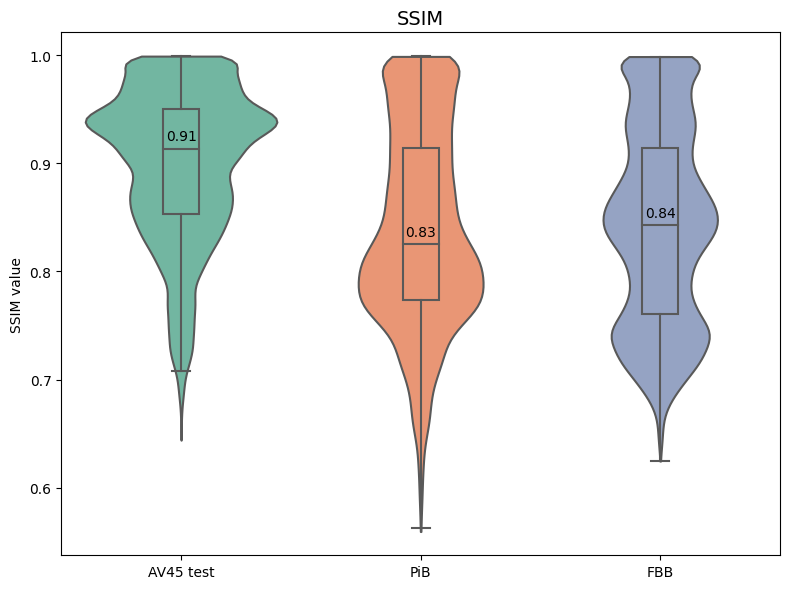

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = [ssim_test, ssim_pib, ssim_fbb]

plt.figure(figsize=(8,6))

# Violin plot
sns.violinplot(data=data, inner=None, palette='Set2', cut=0)

# Box plot overlay without outliers
sns.boxplot(
    data=data, 
    width=0.15, 
    showcaps=True, 
    boxprops={'zorder': 2, 'facecolor': 'none'}, 
    showfliers=False, 
    whiskerprops={'linewidth': 1.5},
    palette='Set2'
)

# Add median annotations
for i, dataset in enumerate(data):
    median_value = np.median(dataset)
    plt.text(
        i, median_value + 0.005,  # x = index, y = median
        f'{median_value:.2f}', 
        ha='center', va='bottom', 
        fontsize=10, color='black'
    )

# Axis labels and title
plt.xticks(range(3), ['AV45 test', 'PiB', 'FBB'])
plt.title("SSIM", fontsize=14)
plt.ylabel("SSIM value")
plt.tight_layout()
plt.show()


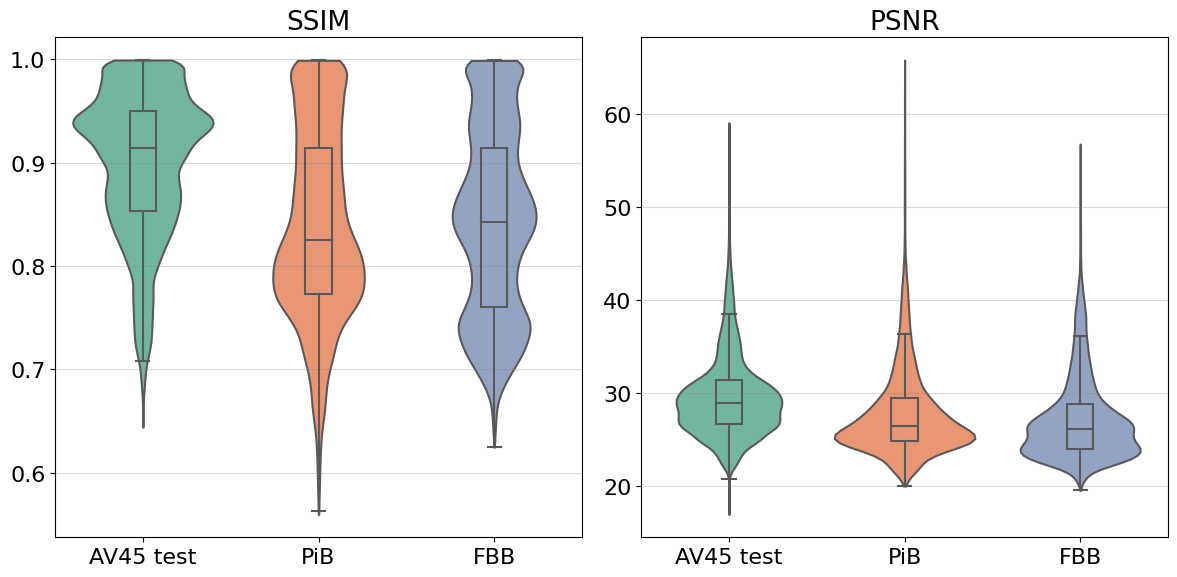

In [30]:
plt.rcParams.update({
    "font.size": 14,              # base font size
    "axes.titlesize": 19,         # title font
    "axes.labelsize": 18,         # x and y labels
    "xtick.labelsize": 16,        # x ticks
    "ytick.labelsize": 16,        # y ticks
    "legend.fontsize": 15        # legend
})

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Example datasets
data1 = [ssim_test, ssim_pib, ssim_fbb]
data2 = [psnr_test, psnr_pib, psnr_fbb]   # replace with your second metric

titles = ["SSIM", "PSNR"]                 # titles for subplots
datasets = [data1, data2]                 # list of lists

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

for ax, data, title in zip(axes, datasets, titles):

    # Violin plot
    sns.violinplot(data=data, inner=None, palette='Set2', cut=0, ax=ax)

    # Boxplot overlay
    sns.boxplot(
        data=data,
        width=0.15,
        showcaps=True,
        boxprops={'zorder': 2, 'facecolor': 'none'},
        showfliers=False,
        whiskerprops={'linewidth': 1.5},
        palette='Set2',
        ax=ax
    )

    # Add median labels
    '''for i, dataset in enumerate(data):
        median_value = np.median(dataset)
        ax.text(
            i+0.2, median_value-(median_value/100),
            f'{median_value:.2f}',
            ha='center', va='bottom',
             color='black'
        )'''

    # Formatting
    ax.set_xticks(range(3))
    ax.set_xticklabels(['AV45 test', 'PiB', 'FBB'])
    ax.set_title(title)
axes[0].grid(axis='y', color='grey', alpha=0.3, linewidth=0.8)
axes[1].grid(axis='y', color='grey', alpha=0.3, linewidth=0.8)

plt.tight_layout()

plt.savefig(path+'/diff_tracers_recon_metrics_'+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
plt.savefig(path+'/diff_tracers_recon_metrics_'+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  

plt.show()


In [26]:
plt.rcParams.update({
    "font.size": 16,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 18,         # x and y labels
    "xtick.labelsize": 16,        # x ticks
    "ytick.labelsize": 16,        # y ticks
    "legend.fontsize": 15        # legend
})

def plot_slices(original_scan, reconstruction_scan,ssim_pet,psnr_pet, name):
    fig = plt.figure(figsize=(12,6))
    index1 = [1,3]
    index2 = [2,4]
    start = 0
    for num, i in enumerate([45,90]):
        
        fig.add_subplot(2, 2, index1[num])
        plt.imshow(np.rot90(original_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        if index1[num] == 1:
            plt.title('Original scan')
        
        fig.add_subplot(2,2, index2[num])
        plt.imshow(np.rot90(reconstruction_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        plt.text(0.95, 0.05, "SSIM="+str(round(ssim_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        plt.text(0.95, 0.85, "PSNR="+str(round(psnr_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        if index2[num] == 2:
            plt.title('Reconstructed scan')
        
        
        plt.subplots_adjust(wspace=-0.7, hspace=0.2) 
        
        #print(ssim_pet[i])
        plt.axis('off')
        plt.savefig(path+name+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
        plt.savefig(path+name+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  

In [27]:
def ssim_function(original_img, recon_img):
    pet = []
    for i in range(original_img.shape[0]):
        pet.append(float(ssim(original_img[i][0], recon_img[i][0], data_range=1)))

        
    return pet

def psnr_function(original_img, recon_img):
    pet = []
    for i in range(original_img.shape[0]):
        pet.append(float(psnr(original_img[i][0], recon_img[i][0], data_range=1)))
    return pet

In [ ]:
pib_dataset = PETMRISliceDataset(list_IDs_pet = file_paths[:1], brain_mask = brain_mask)

pib_dataloader = DataLoader(pib_dataset, batch_size=182,
                        shuffle=False, num_workers=8)

In [34]:
for batch_idx, data in enumerate(pib_dataloader):
    data_batch_train = data['image'].float().to(device) #data['image'].type(torch.FloatTensor).to(device) for CPU
    image_recon_train = model_up(data_batch_train)

    orig_scan = data_batch_train.detach().cpu().numpy()
    recon_scan = image_recon_train[0].detach().cpu().numpy()


In [35]:
pib1_ssim =ssim_function(orig_scan,recon_scan)
pib1_psnr =psnr_function(orig_scan,recon_scan)


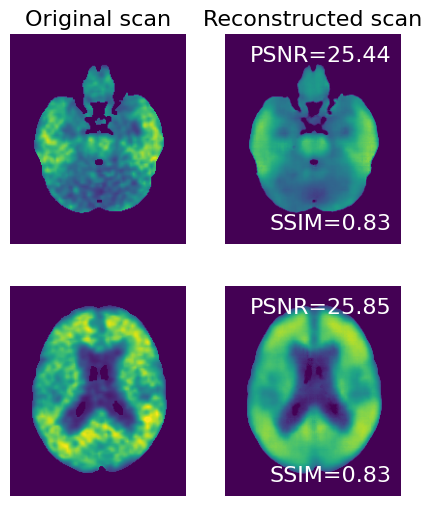

In [47]:
plot_slices(orig_scan,recon_scan,pib1_ssim,pib1_psnr,'/slices_recon_pib1')

In [166]:
recon_scan.shape

(182, 1, 182, 218)

In [28]:
# creating datasets 
fbb_dataset = PETMRISliceDataset(list_IDs_pet = file_paths_fbb[:1], brain_mask = brain_mask)
# creating dataloaders
fbb_dataloader = DataLoader(fbb_dataset, batch_size=182,
                        shuffle=False, num_workers=8)


In [31]:
for batch_idx, data in enumerate(fbb_dataloader):
    data_batch_train = data['image'].float().to(device) #data['image'].type(torch.FloatTensor).to(device) for CPU
    image_recon_train = model_up(data_batch_train)

    orig_scan_fbb = data_batch_train.detach().cpu().numpy()
    recon_scan_fbb = image_recon_train[0].detach().cpu().numpy()


In [32]:
fbb1_ssim =ssim_function(orig_scan_fbb,recon_scan_fbb)
fbb1_psnr =psnr_function(orig_scan_fbb,recon_scan_fbb)


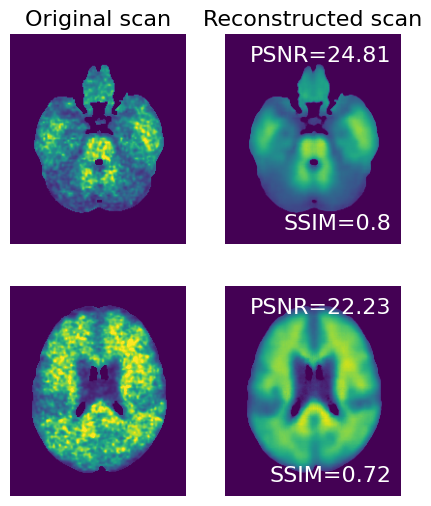

In [33]:
plot_slices(orig_scan_fbb,recon_scan_fbb,fbb1_ssim,fbb1_psnr,'/slices_recon_fbb1')